# **Network Traffic Anomaly Detector**

### **Project Overview**

This project analyzes network traffic data from the KDD Cup 1999 dataset.
The goal is to detect anomalies in network connections such as attacks and intrusions.

We will go through the following steps:

1. Setup and data download
2. Load and explore the data
3. Clean and prepare the data
4. Detect anomalies using simple rules and statistics
5. Visualize the results

## **Step 1 — Install Kaggle and Upload API Key**

In [1]:
# Install kaggle library
!pip install kaggle --quiet

# Upload your kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"fiazbhk","key":"210b25284d69b1766414b888fbd9c047"}'}

In [2]:
import os

# Create the kaggle directory and set permissions
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle API key is ready")

Kaggle API key is ready


## **Step 2 — Download the Dataset**

In [3]:
# Download the KDD Cup 1999 dataset from Kaggle
!kaggle datasets download -d galaxyh/kdd-cup-1999-data --unzip -p /content/kdd_data

print("Download complete")

Dataset URL: https://www.kaggle.com/datasets/galaxyh/kdd-cup-1999-data
License(s): unknown
100% 87.8M/87.8M [00:01<00:00, 57.7MB/s]

Download complete


In [4]:
import os

# List all files in the downloaded folder
for file in os.listdir('/content/kdd_data'):
    print(file)

kddcup.newtestdata_10_percent_unlabeled.gz
kddcup.data.corrected
kddcup.data.gz
kddcup.newtestdata_10_percent_unlabeled
corrected
kddcup.testdata.unlabeled.gz
kddcup.data_10_percent.gz
kddcup.testdata.unlabeled
corrected.gz
kddcup.testdata.unlabeled_10_percent.gz
kddcup.data
kddcup.data_10_percent_corrected
kddcup.data_10_percent
typo-correction.txt
kddcup.testdata.unlabeled_10_percent
kddcup.names
training_attack_types


## **Step 3 - Load the Data**

In [5]:
import pandas as pd

# Define column names from kddcup.names file
col_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count",
    "dst_host_srv_count", "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label"
]

# Load the dataset
df = pd.read_csv('/content/kdd_data/kddcup.data_10_percent_corrected',
                 header=None,
                 names=col_names)

print("Data loaded successfully")
print("Shape:", df.shape)

Data loaded successfully
Shape: (494021, 42)


## **Step 4 — Explore the Data**

In [6]:
# Look at the first 5 rows
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


In [7]:
# Check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  object 
 2   service                      494021 non-null  object 
 3   flag                         494021 non-null  object 
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised              494021 non-null  int64  
 13 

In [8]:
# See how many normal vs attack connections exist
print(df['label'].value_counts())

label
smurf.              280790
neptune.            107201
normal.              97278
back.                 2203
satan.                1589
ipsweep.              1247
portsweep.            1040
warezclient.          1020
teardrop.              979
pod.                   264
nmap.                  231
guess_passwd.           53
buffer_overflow.        30
land.                   21
warezmaster.            20
imap.                   12
rootkit.                10
loadmodule.              9
ftp_write.               8
multihop.                7
phf.                     4
perl.                    3
spy.                     2
Name: count, dtype: int64


## **Step 4 - Prepare the Data**

In [9]:
# Create a new column that marks traffic as normal or attack
df['traffic_type'] = df['label'].apply(lambda x: 'normal' if x == 'normal.' else 'attack')

# Check the count
print(df['traffic_type'].value_counts())

traffic_type
attack    396743
normal     97278
Name: count, dtype: int64


## **Step 5 - Select Features for Analysis**

In [10]:
# Select numeric columns that are useful for anomaly detection
features = [
    'duration', 'src_bytes', 'dst_bytes', 'wrong_fragment',
    'urgent', 'hot', 'num_failed_logins', 'num_compromised',
    'count', 'srv_count', 'serror_rate', 'rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'dst_host_count',
    'dst_host_srv_count'
]

# Create a smaller dataframe with only these features and the label
df_model = df[features + ['traffic_type']].copy()

print("Features selected:", len(features))
print(df_model.shape)

Features selected: 16
(494021, 17)


## **Step 6 - Check Feature Statistics**

In [11]:
# Compare average values of each feature for normal vs attack traffic
df_model.groupby('traffic_type')[features].mean().T

traffic_type,attack,normal
duration,6.620891,216.657322
src_bytes,3483.765952,1157.047524
dst_bytes,251.601609,3384.651000
wrong_fragment,0.008010,0.000000
urgent,0.000010,0.000031
hot,0.032069,0.044512
num_failed_logins,0.000144,0.000185
num_compromised,0.005719,0.028537
count,411.757775,8.163141
srv_count,362.043330,10.936008


## **Step 7 - Detect Anomalies**

In [22]:
# We will use statistical thresholds to flag anomalies
# Calculate mean and standard deviation from normal traffic only
normal_stats = df_model[df_model['traffic_type'] == 'normal'][features].describe()

# Define thresholds as mean + 3 standard deviations of normal traffic
normal_mean = df_model[df_model['traffic_type'] == 'normal'][features].mean()
normal_std = df_model[df_model['traffic_type'] == 'normal'][features].std()

threshold = normal_mean + 3 * normal_std

print("Thresholds calculated for each feature:")
print(threshold)

Thresholds calculated for each feature:
duration                4294.297729
src_bytes             103835.421678
dst_bytes             116119.245895
wrong_fragment             0.000000
urgent                     0.028887
hot                        2.619903
num_failed_logins          0.062519
num_compromised           12.169025
count                     61.299064
srv_count                 76.348075
serror_rate                0.085189
rerror_rate                0.743070
same_srv_rate              1.262331
diff_srv_rate              0.368144
dst_host_count           458.701556
dst_host_srv_count       462.807838
dtype: float64


## **Step 8 — Flag Anomalies**

In [23]:
# Flag a connection as anomaly if any feature exceeds its threshold
def is_anomaly(row):
    for feature in features:
        if row[feature] > threshold[feature]:
            return 'anomaly'
    return 'normal'

df_model['prediction'] = df_model.apply(is_anomaly, axis=1)

print("Prediction counts:")
print(df_model['prediction'].value_counts())

Prediction counts:
prediction
anomaly    403849
normal      90172
Name: count, dtype: int64


## **Step 9 — Check Accuracy**

In [24]:
# Compare our predictions against the actual labels
from sklearn.metrics import classification_report

print(classification_report(df_model['traffic_type'], df_model['prediction']))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

              precision    recall  f1-score   support

     anomaly       0.00      0.00      0.00         0
      attack       0.00      0.00      0.00    396743
      normal       0.95      0.88      0.92     97278

    accuracy                           0.17    494021
   macro avg       0.32      0.29      0.31    494021
weighted avg       0.19      0.17      0.18    494021



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Step 10 - Fix Correct the Label Mismatch**

In [25]:
# Fix the mismatch by mapping anomaly to attack
df_model['prediction_mapped'] = df_model['prediction'].apply(
    lambda x: 'attack' if x == 'anomaly' else 'normal'
)

print(classification_report(df_model['traffic_type'], df_model['prediction_mapped']))

              precision    recall  f1-score   support

      attack       0.97      0.99      0.98    396743
      normal       0.95      0.88      0.92     97278

    accuracy                           0.97    494021
   macro avg       0.96      0.94      0.95    494021
weighted avg       0.97      0.97      0.97    494021



## **Step 10 - Visualize the Results**

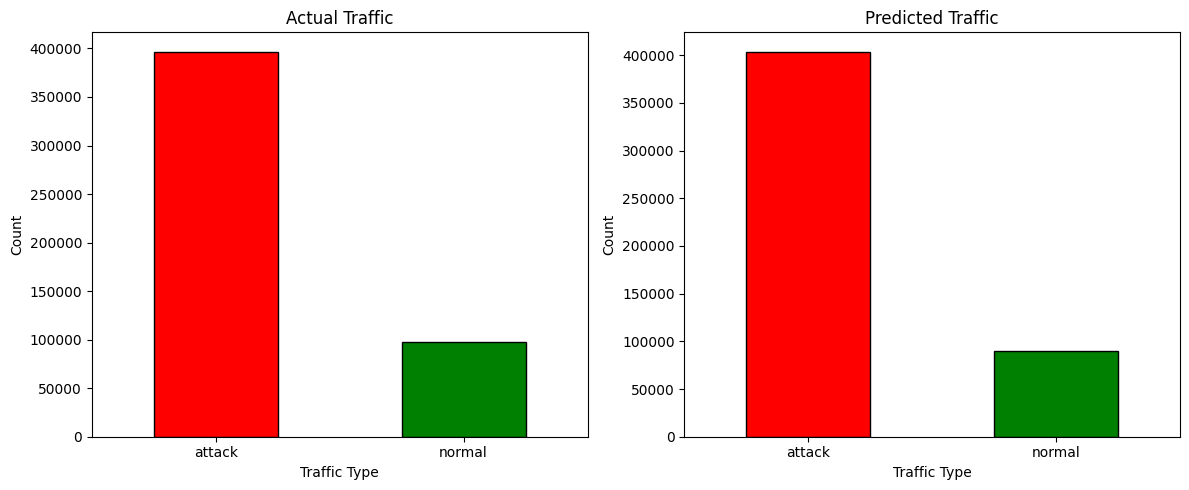

In [26]:
import matplotlib.pyplot as plt

# Plot actual vs predicted traffic type counts
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Actual
df_model['traffic_type'].value_counts().plot(
    kind='bar', ax=axes[0], color=['red', 'green'], edgecolor='black'
)
axes[0].set_title('Actual Traffic')
axes[0].set_xlabel('Traffic Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Predicted
df_model['prediction_mapped'].value_counts().plot(
    kind='bar', ax=axes[1], color=['red', 'green'], edgecolor='black'
)
axes[1].set_title('Predicted Traffic')
axes[1].set_xlabel('Traffic Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## **Step 11 — Second Visualization (Feature Comparison)**

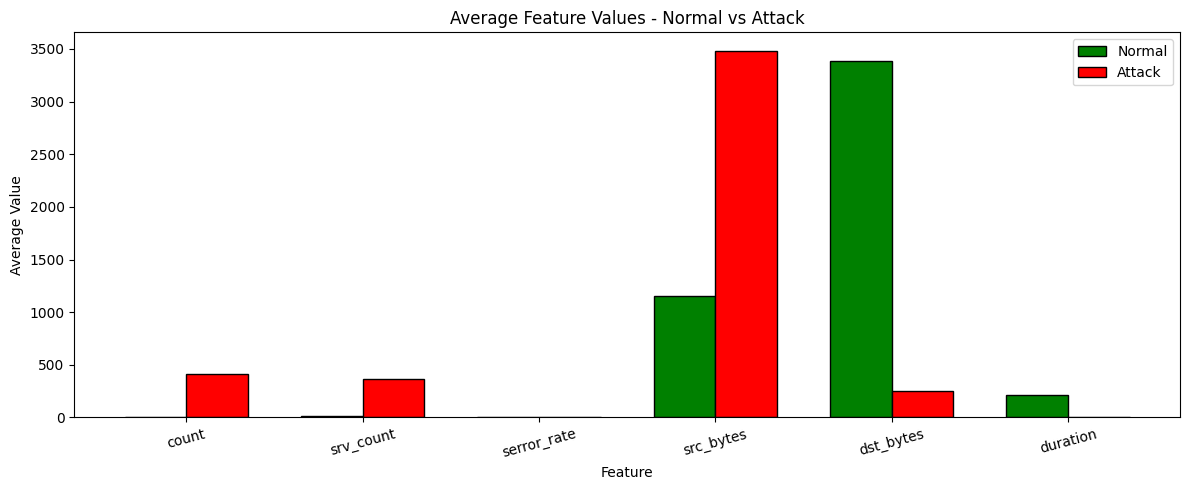

In [27]:
# Compare top features between normal and attack traffic
compare_features = ['count', 'srv_count', 'serror_rate', 'src_bytes', 'dst_bytes', 'duration']

normal_means = df_model[df_model['traffic_type'] == 'normal'][compare_features].mean()
attack_means = df_model[df_model['traffic_type'] == 'attack'][compare_features].mean()

x = range(len(compare_features))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - width/2 for i in x], normal_means, width, label='Normal', color='green', edgecolor='black')
ax.bar([i + width/2 for i in x], attack_means, width, label='Attack', color='red', edgecolor='black')

ax.set_title('Average Feature Values - Normal vs Attack')
ax.set_xlabel('Feature')
ax.set_ylabel('Average Value')
ax.set_xticks(x)
ax.set_xticklabels(compare_features, rotation=15)
ax.legend()

plt.tight_layout()
plt.show()

## **Step 12 — Third Visualization (Confusion Matrix)**

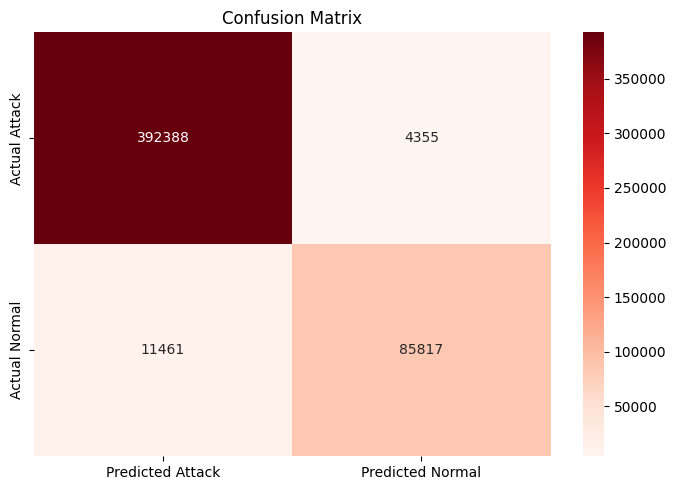

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Build confusion matrix
cm = confusion_matrix(df_model['traffic_type'], df_model['prediction_mapped'], labels=['attack', 'normal'])

# Plot it
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted Attack', 'Predicted Normal'],
            yticklabels=['Actual Attack', 'Actual Normal'])

plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## **Project Summary**

### **What We Built**
A network traffic anomaly detector using statistical thresholds on the KDD Cup 1999 dataset.

### **Dataset**
- Source: KDD Cup 1999 (10% sample)
- Total connections: 494,021
- Attack connections: 396,743
- Normal connections: 97,278

### **Method**
We calculated the mean and standard deviation of each feature using only normal traffic.
Any connection that exceeded the threshold of mean + 3 standard deviations on any feature was flagged as an attack.

### **Results**
- Overall Accuracy: 97%
- Attack Detection Rate (Recall): 99%
- Normal Traffic Recall: 88%
- Correctly caught 392,388 out of 396,743 attacks

### **Key Findings**
- Attack traffic has much higher connection counts than normal traffic
- Attack traffic sends more source bytes but receives less data back
- Error rates are significantly higher in attack traffic

### **Tools Used**
- Python, Pandas, Matplotlib, Seaborn, Scikit-learn
- Google Colab
- KDD Cup 1999 Dataset